Download Datasets


In [ ]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2026-03-11 13:28:44--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.218.186.60, 2600:1409:3c00:c80::317f, 2600:1409:3c00:c8c::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.218.186.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   170MB/s    in 4.6s    

2026-03-11 13:28:49 (171 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [ ]:
# Unzip The Dataset
!unzip kagglecatsanddogs_5340.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from keras.preprocessing.image import load_img
import os
import tqdm
import random
warnings.filterwarnings('ignore')

In [ ]:
# create a dataframe for input and output
input_path = []
label = []

for clas in os.listdir('PetImages'):
  for path in tqdm.tqdm(os.listdir('PetImages/'+clas)):
    if clas == 'Cat':
      label.append(0)
    else:
      label.append(1)

    input_path.append(os.path.join('PetImages',clas, path))
print(input_path[0],label[0])



100%|██████████| 12501/12501 [00:00<00:00, 701942.44it/s]

PetImages/Cat/11954.jpg 0


In [ ]:
print(f"{input_path[1]},{label[1]}")

PetImages/Cat/11308.jpg,0


In [ ]:
len(label)

25002

In [ ]:
df = pd.DataFrame()
df['images'] = input_path
df['labels'] = label
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,images,labels
0,PetImages/Cat/9876.jpg,0
1,PetImages/Cat/326.jpg,0
2,PetImages/Cat/994.jpg,0
3,PetImages/Cat/6082.jpg,0
4,PetImages/Dog/4705.jpg,1


In [ ]:
#delete db files
for i in df['images']:
  if '.jpg' not in i:
    print(i)


PetImages/Cat/Thumbs.db
PetImages/Dog/Thumbs.db


In [ ]:
df = df[df['images']!='PetImages/Cat/Thumbs.db']
df = df[df['images']!='PetImages/Dog/Thumbs.db']
df = df[df['images']!='PetImages/Cat/666.jpg']
df = df[df['images']!='PetImages/Dog/11702.jpg']


len(df)

24998

In [ ]:
import PIL.Image
l = []
for image in df['images']:
  try:
     img = PIL.Image.open(image)
  except:
    l.append(image)
l

['PetImages/Cat/666.jpg', 'PetImages/Dog/11702.jpg']

In [ ]:
print(f"Number of corrupted images: {len(l)}")

Number of corrupted images: 25000


In [ ]:
# Exploratry Data Analysis

plt.figure(figsize=(25,25))
temp = df[df['labels']==1]['images']
start = random.randint(0,len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
  plt.subplot(5,5,index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title("DOgs")
  plt.axis('off')


<Figure size 2500x2500 with 0 Axes>

In [ ]:
# Exploratry Data Analysis

plt.figure(figsize=(25,25))
temp = df[df['labels']==0]['images']
start = random.randint(0,len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
  plt.subplot(5,5,index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title("Cats")
  plt.axis('off')


<Figure size 2500x2500 with 0 Axes>

In [ ]:
df['labels'] = df['labels'].astype('str')

In [ ]:
df['labels'].value_counts()

,count
labels,
0,12499
1,12499


In [ ]:
#input split
from sklearn.model_selection import train_test_split
train,test = train_test_split(df,test_size=0.2, random_state=42)

In [ ]:
train.head()

,images,labels
23288,PetImages/Cat/9596.jpg,0
17783,PetImages/Cat/555.jpg,0
1020,PetImages/Cat/309.jpg,0
12646,PetImages/Dog/9211.jpg,1
1533,PetImages/Cat/10153.jpg,0


In [ ]:
from keras.src.layers import RandomRotation
# create a datagenerator for the images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_generator = ImageDataGenerator(
    rescale=1./255, # normalizing
    rotation_range = 40,  # augmentation of images to avoid overfitting
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

val_generator = ImageDataGenerator(
    rescale=1./255,

)

train_iterator = train_generator.flow_from_dataframe(train,
                                                     x_col = 'images',
                                                     y_col='labels',
                                                     target_size = (128,128),
                                                     batch_size=64,
                                                     class_mode='binary'
)

val_iterator = train_generator.flow_from_dataframe(test,
                                                     x_col = 'images',
                                                     y_col='labels',
                                                     target_size = (128,128),
                                                     batch_size=64,
                                                     class_mode='binary'
)


Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [ ]:
# MOdel Creations
from keras import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

In [ ]:
from torch.nn.modules.conv import Conv2d
model = Sequential()
model.add(Conv2D(16,(3,3),activation = 'relu',input_shape = (128,128,3)))
model.add(MaxPool2D((2,2)))
model.add(Conv2D(32,(3,3),activation = 'relu'))
model.add(MaxPool2D((2,2)))
model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(MaxPool2D((2,2)))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))


In [ ]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,137 (24.59 MB)

 Trainable params: 6,447,137 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_iterator, epochs=10, validation_data = val_iterator)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 407ms/step - accuracy: 0.8920 - loss: 0.2530 - val_accuracy: 0.8494 - val_loss: 0.3431
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 404ms/step - accuracy: 0.8864 - loss: 0.2633 - val_accuracy: 0.8704 - val_loss: 0.2990
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 411ms/step - accuracy: 0.8946 - loss: 0.2501 - val_accuracy: 0.8706 - val_loss: 0.3027
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 405ms/step - accuracy: 0.8991 - loss: 0.2372 - val_accuracy: 0.8796 - val_loss: 0.2946
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 410ms/step - accuracy: 0.8999 - loss: 0.2419 - val_accuracy: 0.8724 - val_loss: 0.3071
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 405ms/step - accuracy: 0.9109 - loss: 0.2231 - val_accuracy: 0.8796 - val_loss: 0.2813
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 404ms/step - accuracy: 0.9084 - loss: 0.2232 - val_accuracy: 0.8742 - val_loss: 0.2883
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 402ms/step - accuracy: 0.9091 -

<Figure size 640x480 with 0 Axes>

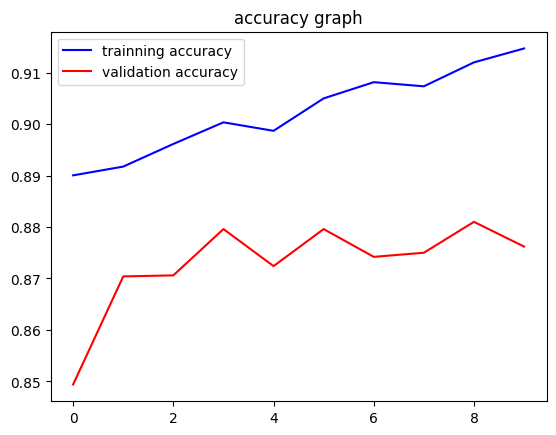

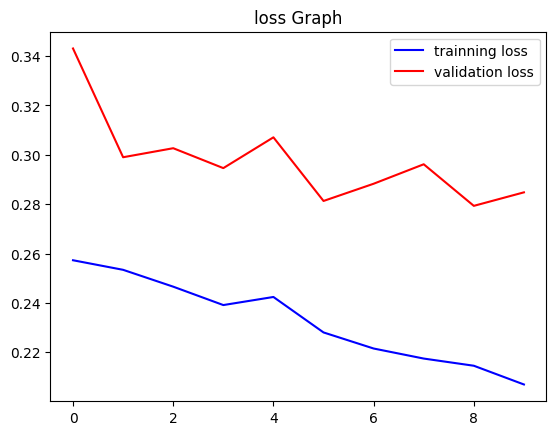

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label = "trainning accuracy")
plt.plot(epochs, val_acc, 'r', label = "validation accuracy")
plt.title("Training and Validation Accuracy")
plt.title('accuracy graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, 'b', label = "trainning loss")
plt.plot(epochs, val_loss, 'r', label = "validation loss")
plt.title("Training and Validation Accuracy")
plt.title('loss Graph')
plt.legend()
plt.figure()

In [ ]:
from sklearn.metrics import classification_report
y_pred = model.predict(val_iterator)
y_pred = np.round(y_pred)


79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 320ms/step


In [ ]:
print(classification_report(val_iterator.classes, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.52      0.50      2485
           1       0.49      0.47      0.48      2515

    accuracy                           0.49      5000
   macro avg       0.49      0.49      0.49      5000
weighted avg       0.49      0.49      0.49      5000

